In [1]:
#SJL 3/2023
#Script to plot a comparison of the the change in surface length for example tidal evolution scenarios

###########################################################
###########################################################
###########################################################
import numpy as np
import scipy as sp
import sys
import os
import struct
from scipy import constants as const

#package to use wildcards 
import fnmatch

import csv
import time as tclock

from scipy.interpolate import LinearNDInterpolator
from scipy.interpolate import griddata

#plotting packages
import matplotlib as mpl
import matplotlib.pyplot as plt
import pylab
import matplotlib.cm as cm
from matplotlib import gridspec


cwd = os.getcwd()
print(cwd)
if sys.platform== 'darwin':
    sys.path.insert(0, cwd+'/Support_scipts')
    print(cwd+'/Support_scripts')
elif (sys.platform== 'win32') | (sys.platform== 'win64'):
    sys.path.insert(0,cwd+"\\Support_scipts")
    
#HERCULES_structures
from HERCULES_structures import *
from surface_size_calc import *
from HERCULES_random_planet_database_structure_1D import *

#functions for calculating non-evenly spaced numerical differentials
from gradients import *

#import colormaps
import colormaps as cmaps
import matplotlib.cm as cm

import svglib.svglib as svglib
svglib.register_font('helvetica', './Helvetica.ttc')

/Users/vq21447/Documents/Lock_2026_SI
/Users/vq21447/Documents/Lock_2026_SI/Support_scripts
CHECK THE LOCATION OF ODYSSEY BACKUP
CHECK THE LOCATION OF ODYSSEY BACKUP


('helvetica', True)

In [2]:
########################################################################################
########################################################################################
########################################################################################
#CONSTANTS
MEarth=5.972E24
LEM=3.5E34
REarth=6.371E6
MMoon=7.34767309E22

aMoon=0.3844E9
aCassini=30*REarth
aRoche=2.9*REarth

#for HERCULES
MEarth_H=5.9879648E24
LEM_H=3.53E34

In [3]:
########################################################################################
########################################################################################
########################################################################################
#PARAMS
#info for HERCULES arrays
Hdir='Earth_correct_params_S3.20c'
Hname='Earth_correct_params_S3.20c'

#Earth's moment of inertia used to convert to AM
C_Earth=0.335

#which plot do you want
#0: A=5, tau=49E5, Q/k=406
#1: A=500, tau=200E5, Q/k=406
#2: A=10000, tau=1500E5, Q/k=406
#Give data files (for all cases)
dir='Data_repo/Rufu&Canup_2020_quasi_resonance/ResultsEvection_2'
file_names=['EvolutionA5_Tau49.0e5_Phi0.txt',
            'EvolutionA500_Tau200.0e5_Phi0.txt',
            'EvolutionA10000_Tau1500.0e5_Phi0.txt']

#output file root
data_output_file_root='Rufu&Canup_surf_change'

#directory to find procesed length data
data_dir='Data_repo/Rufu&Canup_2020_quasi_resonance'


In [4]:
########################################################################################
########################################################################################
########################################################################################
#MAIN

########################################################################################
#read in the database

Hdatabase=HERCULES_random_planet_database_1D()
Hdatabase.make_array(Hdir,Hname)
Hdatabase.initialize_interpolation([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                   [0,0,[],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]], flag_extrap=1)

#extract the latitudes for each Mu point
Nmu=Hdatabase.parr[0].Nmu
lat=np.arccos(Hdatabase.parr[0].layers[0].mu)*180/np.pi


Earth_correct_params_S3.20c
	 Earth_correct_params_S3.20c_AM3.3125
	 Earth_correct_params_S3.20c_AM3.30625
	 Earth_correct_params_S3.20c_AM3.325


In [5]:
#read in the orbital evolution data
Ctime=[]
CkQ=[]
Ca=[]
Comg=[]
Comg_moon=[]
Ce=[]
Cphi=[]
omg_norm=[]
CL_tot=[]
CL=[]

Aset=[]
tau_set=[]

for k in np.arange(3):
    print(k, file_names[k])
    fdata=open(dir+'/'+file_names[k])

    reader = csv.reader(fdata, delimiter="\t", skipinitialspace=True)
    temp = list(reader)

    Ctime.append([])
    CkQ.append([])
    Ca.append([])
    Comg.append([])
    Comg_moon.append([])
    Ce.append([])
    Cphi.append([])
    omg_norm.append([])
    CL_tot.append([])
    CL.append([])

    for i in np.arange(len(temp)):

        if i==0:
            temp2=temp[i][0]
            Aset.append(float(temp2[6:]))
            print(Aset[k])

        elif i==1:
            temp2=temp[i][0]
            tau_set.append(float(temp2[13:]))
            print(tau_set[k])

        elif (i>3)&(np.size(temp[i])>3):

            Ctime[k].append(temp[i][0]) #time
            Comg[k].append(temp[i][1]) #rotation rate of Earth
            Comg_moon[k].append(temp[i][2]) #rotation rate of Moon
            Ce[k].append(temp[i][3]) #eccentricity
            Ca[k].append(temp[i][4]) #semi-major axis
            Cphi[k].append(temp[i][5]) #Phi parameter related to tidal lag


    #convert to useful type and units
    omg_norm[k]=np.sqrt(const.G*MEarth/(REarth**3))
    Ctime[k]=np.asarray(Ctime[k], dtype=np.float64)*1E4
    Ca[k]=np.asarray(Ca[k], dtype=np.float64)*REarth
    Ce[k]=np.asarray(Ce[k], dtype=np.float64)
    Comg[k]=np.asarray(Comg[k], dtype=np.float64)*omg_norm[k]
    Comg_moon[k]=np.asarray(Comg[k], dtype=np.float64)*omg_norm[k]

    #calculate the AM and de-normalize
    CL_tot[k]=Comg[k]/omg_norm[k]+1.07E-3*Comg_moon[k]/omg_norm[k]+0.0367*np.sqrt(Ca[k]/REarth*(1-Ce[k]**2))
    CL_tot[k]=CL_tot[k]*C_Earth*MEarth*REarth**2*omg_norm[k]

    CL[k]=Comg[k]*C_Earth*MEarth*REarth**2

     

print('done')

0 EvolutionA5_Tau49.0e5_Phi0.txt
5.0
4900000.0
1 EvolutionA500_Tau200.0e5_Phi0.txt
500.0
20000000.0
2 EvolutionA10000_Tau1500.0e5_Phi0.txt
10000.0
150000000.0
done


In [6]:
#load in the max deformation rate data
print('start')
    
steps=[]
time=[]
ddl_lon_dt_max=[]
ddl_lon_dt_min=[]
ddl_lat_dt_min=[]
ddl_lat_dt_max=[]

for i in np.arange(3):
#define an output file
    data_output_file=data_dir+'/'+data_output_file_root+'_A_'+str(Aset[i])+'_tau_'+str(tau_set[i]/1E5)+'E5.bin'
    data_output_file_int=data_dir+'/'+data_output_file_root+'_max_integrated_A_'+str(Aset[i])+'_tau_'+str(tau_set[i]/1E5)+'E5.bin'
   
    #read in the max deformation data 
    dataf_int = open(data_output_file_int, "rb")

    #read in the file as one massive array
    ndata_per_step=6
    data = np.fromfile(dataf_int, dtype=np.float64, count=-1)
    dataf_int.close()

    #work out how many time steps we have
    temp=np.size(data)*1.0/(1.0*ndata_per_step)
    if abs(temp-int(temp))<(1E-12):
        Ntstep=int(temp)
    else:
        print("ERROR IN READ",'\n',"Not complete number of steps or incorrect number of print params",'\n',"EXITING")

    #reshape array so that each row is a timestep
    data=data.reshape(Ntstep,ndata_per_step)

    steps.append(data[:,0].astype(int))
    time.append(data[:,1])
    ddl_lon_dt_max.append(data[:,2])
    ddl_lon_dt_min.append(data[:,3])
    ddl_lat_dt_min.append(data[:,4])
    ddl_lat_dt_max.append(data[:,5])

print('end')
    
    

start
end


done


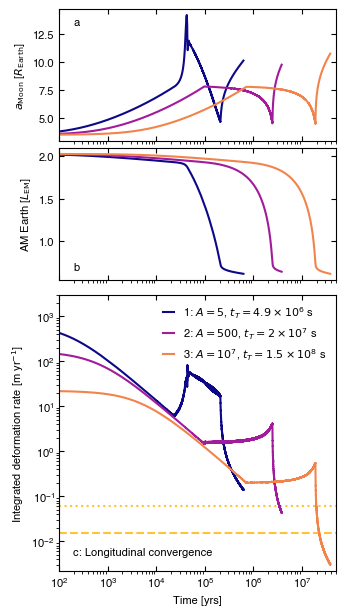

In [7]:
# print('start')

#create a dummy figure figure first to avoid plotting issues
fig = plt.figure(figsize=(3.9,6.5))
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])
fig.tight_layout()
plt.savefig('Figure9.pdf')
mpl.pyplot.close(fig)

#Now make the real figure
labels=[r'1: $A=5$, $t_T=4.9\times 10^6$ s', r'2: $A=500$, $t_T=2\times 10^7$ s', r'3: $A=10^{7}$, $t_T=1.5\times 10^8$ s']

#initialise the figure
fig = plt.figure(figsize=(3.5,6.2))

gs0 = gridspec.GridSpec(2, 1,
                        width_ratios=[1],
                        height_ratios=[1,1.02],
                        )

gs000 = gridspec.GridSpecFromSubplotSpec(2, 1, 
                                    subplot_spec=gs0[0],
                                    height_ratios=[1,1],
#                                         hspace=0.05,
#                                         wspace=0.05
                                    )


ax=[[],[],[]]
# ax[0].append(plt.subplot(gs0[1]))

ax[0].append(plt.subplot(gs0[1]))

ax[2].append(plt.subplot(gs000[0], sharex=ax[0][0]))
ax[2].append(plt.subplot(gs000[1], sharex=ax[0][0]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)

col=cmaps.parula([0.15,0.85])
col2=cmaps.plasma([0,0.35,0.7])

xlim=[1E2,5E7]

ind_max=-1
# ax[0][0].plot(xlim,[8E-3,8E-3],'--', color=col[0],linewidth=1.5) #slow mid ocean ridge
ax[0][0].plot(xlim,[15E-3,15E-3],'--', color=col[1],linewidth=1.5) #slow subduction
# ax[0][0].plot(xlim,[50E-3,50E-3],':', color=col[0],linewidth=1.5) #average mid-ocean ridge
ax[0][0].plot(xlim,[60E-3,60E-3],':', color=col[1],linewidth=1.5) #avererage subduction
#ax[0][0].plot([0,t[ind_max]/1E6],[4E-4,4E-4],'b--') 


for i in np.arange(3):

    ax[2][0].plot(Ctime[i], Ca[i]/REarth, '-', color=col2[i], linewidth=1.5)
    ax[2][1].plot(Ctime[i], CL[i]/LEM, '-', color=col2[i], linewidth=1.5)
    
#     ax[0][0].plot(time[i], np.absolute(ddl_lon_dt_max[i]),'-', color=col2[i],linewidth=1.5)
    ax[0][0].plot(time[i], np.absolute(ddl_lon_dt_min[i]),'-', color=col2[i],linewidth=1.5, label=labels[i])




ax[0][0].set_yscale('log')

ax[2][0].set_xscale('log')
ax[2][1].set_xscale('log')
ax[0][0].set_xscale('log')


ax[2][0].set_xlim(xlim)
ax[2][1].set_xlim(xlim)
ax[0][0].set_xlim(xlim)

ax[0][0].set_ylim([2.2E-3,3E3])


ax[2][0].set_ylabel(r"$a_{\rm Moon}$ [$R_{\rm Earth}$]")
ax[2][1].set_ylabel(r"AM Earth [$L_{\rm EM}$]")

ax[0][0].set_ylabel('Integrated deformation rate [m yr$^{-1}$]')

ax[0][0].set_xlabel('Time [yrs]')

plt.setp( ax[2][0].get_xticklabels(), visible=False)
plt.setp( ax[2][1].get_xticklabels(), visible=False)

ax[2][0].tick_params(direction="in", top=True, right=True)
ax[2][1].tick_params(direction="in", top=True, right=True)
ax[0][0].tick_params(direction="in", top=True)

    
ax[0][0].legend(frameon=False, handlelength=1.0, loc='upper right')
    
    
ax[0][0].text(0.05, 0.05, 'c: Longitudinal convergence', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][0].transAxes, color='k')
       

ax[2][0].text(0.05, 0.94, 'a', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[2][0].transAxes, color='k')
ax[2][1].text(0.05, 0.06, 'b', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[2][1].transAxes, color='k')
  

fig.tight_layout()


plt.savefig('Figure9.pdf')

print('done')